 has to be removed hardcoded part !/users/man-chun.yeung/microlensing/env/bin/python3

In [1]:
import sys
import os
path = os.getcwd()
dir = os.path.abspath(os.path.join(path, os.pardir))
dir = '/home/manchun.yeung/microlensing/wolensing/wolensing'
sys.path.append(dir)
import amplification_factor.amplification_factor as af

In [2]:
from jax import config
config.update("jax_enable_x64", True)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from argparse import ArgumentParser

In [4]:
from lenstronomy.LensModel.lens_model import LensModel
import lensinggw.constants.constants as const
from lensinggw.utils.utils import TimeDelay, magnifications, getMinMaxSaddle
from lensinggw.amplification_factor.amplification_factor import geometricalOpticsMagnification

In [5]:
G = const.G  # gravitational constant [m^3 kg^-1 s^-2]
c = const.c  # speed of light [m/s]
M_sun = const.M_sun  # Solar mass [Kg]

In [6]:
imindex = 1

coordinates in scaled units [x (radians) /thetaE_tot]

In [7]:
y0, y1 = 0.1, 0 # source position
l0, l1 = 0.05, 0 # lens position

In [117]:
ym = 0.1
angle = np.radians(float(0.))
zS = 1.0
zL = 0.5

masses

In [118]:
mL1 = 1 * 1e10
mL2 = 50
mtot = mL1 + mL2

convert to radians

In [119]:
from lensinggw.utils.utils import param_processing

In [120]:
thetaE1 = param_processing(zL, zS, mL1)
thetaE2 = param_processing(zL, zS, mL2)
thetaE = param_processing(zL, zS, mtot)

In [121]:
beta0, beta1 = y0 * thetaE, y1 * thetaE
eta10, eta11 = 0 * l0 * thetaE, 0 * l1 * thetaE

In [122]:
lens_model_list = ['SIS']
kwargs_sis_1 = {'center_x': eta10, 'center_y': eta11, 'theta_E': thetaE1}
kwargs_lens_list = [kwargs_sis_1]

In [123]:
print('thetaE1 and thetaE', thetaE1, thetaE)
kwargs_sis_1_scaled = {'center_x': eta10 / thetaE, 'center_y': eta11 / thetaE, 'theta_E': thetaE1 / thetaE}
kwargs_lens_list_scaled = [kwargs_sis_1_scaled]
from lensinggw.solver.images import microimages

thetaE1 and thetaE 8.052888061582411e-07 8.052888081714632e-07


In [124]:
solver_kwargs = {'SearchWindowMacro': 10 * thetaE1,
                 'SearchWindow': 5 * thetaE2,
                 'OverlapDistMacro': 1e-17,
                 'OnlyMacro': True}

In [125]:
MacroImg_ra, MacroImg_dec, pixel_width = microimages(source_pos_x=beta0,
                                                     source_pos_y=beta1,
                                                     lens_model_list=lens_model_list,
                                                     kwargs_lens=kwargs_lens_list,
                                                     **solver_kwargs)


---- Will perform only the macromodel analysis ----

---- Solver settings ----

The macromodel analysis will be performed with the following settings:

OnlyMacro         --> True
Scaled            --> False
SearchWindowMacro --> 8.052888061582412e-06
PixelsMacro       --> 1000
PrecisionLimit    --> 1e-20
OverlapDistMacro  --> 1e-17
NearSource        --> False
Optimization      --> False
Verbose           --> False




MACROIMAGES

ra: [-7.24759925e-07  8.85817687e-07]
dec: [-4.23516474e-22 -4.23516474e-22]



In [126]:
Macromus = magnifications(MacroImg_ra, MacroImg_dec, lens_model_list, kwargs_lens_list)
T01 = TimeDelay(MacroImg_ra, MacroImg_dec,
                beta0, beta1,
                zL, zS,
                lens_model_list, kwargs_lens_list)

In [127]:
imindex = np.nonzero(T01)[0][0]

# lens model

In [128]:
eta20, eta21 = MacroImg_ra[imindex] + np.cos(angle)*ym*thetaE2, MacroImg_dec[imindex] + np.sin(angle)*ym*thetaE2

In [129]:
lens_model_list = ['SIS', 'POINT_MASS']
kwargs_sis_1 = {'center_x': eta10, 'center_y': eta11, 'theta_E': thetaE1}
kwargs_point_mass_2 = {'center_x': eta20, 'center_y': eta21, 'theta_E': thetaE2}
kwargs_lens_list = [kwargs_sis_1, kwargs_point_mass_2]

In [130]:
from lensinggw.solver.images import microimages
solver_kwargs = {'SearchWindowMacro': 10 * thetaE1,
                 'SearchWindow': 40 * thetaE2,
                 'Pixels': 5*1e3,
                 # 'ImgIndex': 1,
                 'Optimization': True,
                 'OverlapDist': 1e-18,
                 'OverlapDistMacro': 1e-17}
solver_kwargs.update({'Improvement' : 0.1})
solver_kwargs.update({'MinDist' : 10**(-7)})

Img_ra, Img_dec, MacroImg_ra, MacroImg_dec, pixel_width = microimages(source_pos_x=beta0,
                                                                      source_pos_y=beta1,
                                                                      lens_model_list=lens_model_list,
                                                                      kwargs_lens=kwargs_lens_list,
                                                                      **solver_kwargs)


---- Solver settings ----

The macromodel analysis will be performed with the following settings:

OnlyMacro                       --> False
Scaled                          --> False
SearchWindowMacro               --> 8.052888061582412e-06
PixelsMacro                     --> 1000
OverlapDistMacro                --> 1e-17
NearSource                      --> False
Optimization                    --> True
Verbose                         --> False
OptimizationWindowMacro         --> 2
OptimizationPixelsMacro         --> 30
MinDistMacro                    --> None
ImprovementMacro                --> None
OptimizationPrecisionLimitMacro --> 1e-20




MACROIMAGES

ra: [-7.24759925e-07  8.85817687e-07]
dec: [-4.23516474e-22 -4.23516474e-22]


---- Solver settings ----

The complete model analysis will be performed with the following settings:

Scaled                          --> False
OnlyMacro                       --> False
MacroIndex                      --> [0]
ImgIndex                  

In [131]:
# from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
# from lenstronomy.LensModel.lens_model import LensModel
# lensmodel = LensModel(lens_model_list=lens_model_list)
# solver = LensEquationSolver(
#     lensModel = lensmodel
# )
# Img_ra, Img_dec = solver.image_position_stochastic(
#     source_x = beta0,
#     source_y = beta1,
#     kwargs_lens = kwargs_lens_list,
#     # min_distance = 1e-13,
#     # solver='lenstronomy'
#     search_window = 20*thetaE2,
#     # verbose=True,
#     precision_limit=10**(-17),
#     x_center = MacroImg_ra[0],
#     y_center= MacroImg_dec[0]
# )

In [132]:
# Img_ra, Img_dec 

In [133]:
Img_ra = np.delete(Img_ra, [-1])
Img_dec = np.delete(Img_dec, [-1])

[-7.24814092e-07 -7.24700065e-07] [-4.24839963e-22 -4.24839963e-22] Img_pos


<Axes: >

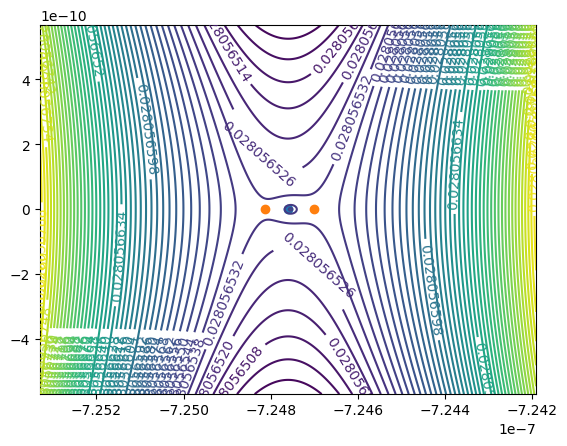

In [134]:
import matplotlib.pyplot as plt
from plot.plot import plot_contour

fig1, ax1 = plt.subplots()
plot_contour(ax1, lens_model_list, MacroImg_ra[0], MacroImg_dec[0], 20*thetaE2, kwargs_lens_list, beta0, beta1, Img_ra, Img_dec,
                    T0 = T0, Tfac = (thetaE)**(-2), micro=True)


In [135]:
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions
# lens_model_list = ['POINT_MASS']
lens_model_complete = LensModel(lens_model_list=lens_model_list)
lensmodelext = LensModelExtensions(lens_model_complete)
ra_crit_list, dec_crit_list = lensmodelext.critical_curve_tiling(kwargs_lens_list, 10*thetaE2, start_scale = thetaE2/100, center_x=MacroImg_ra[0], center_y=MacroImg_dec[0])
ra_caustic_list, dec_caustic_list = lens_model_complete.ray_shooting(ra_crit_list, dec_crit_list, kwargs_lens_list)
macro_srcx, macro_srcy = lens_model_complete.ray_shooting(MacroImg_ra, MacroImg_dec, kwargs_lens_list)
lens_srcx, lens_srcy = lens_model_complete.ray_shooting(eta20, eta21, kwargs_lens_list)

In [136]:
macro_srcx

array([8.10983060e-08, 8.05288788e-08])

[-7.24814092e-07 -7.24700065e-07] [-4.24839963e-22 -4.24839963e-22] Img_pos


<Axes: >

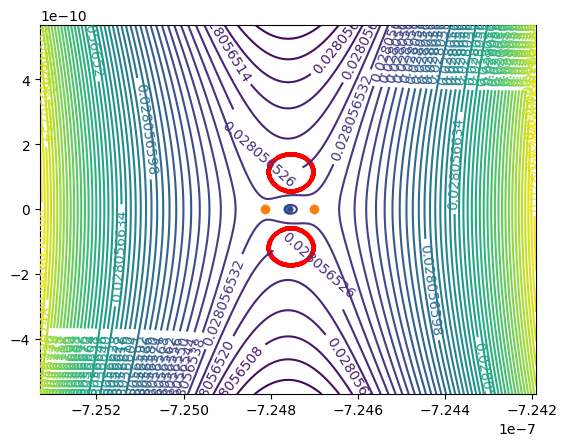

In [137]:
import matplotlib.pyplot as plt
from plot.plot import plot_contour

fig1, ax1 = plt.subplots()
plot_contour(ax1, lens_model_list, MacroImg_ra[0], MacroImg_dec[0], 20*thetaE2, kwargs_lens_list, beta0, beta1, Img_ra, Img_dec, crit_ra = ra_crit_list, crit_dec =dec_crit_list, 
                    T0 = T0, Tfac = (thetaE)**(-2), micro=True)
# plt.savefig('./t2_cusp.png')

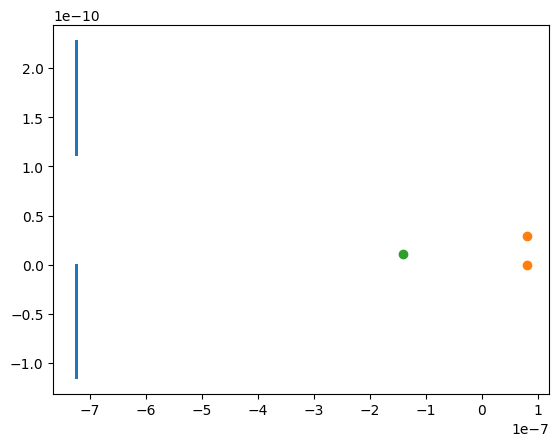

In [94]:
plt.scatter(ra_crit_list, dec_crit_list, s=1)
plt.scatter(macro_srcx, macro_srcy)
plt.scatter(lens_srcx, lens_srcy)
# plt.scatter(circles_x, circles_y, s=0.5)

time delays, magnifications, Morse indices and amplification factor

In [23]:
from lensinggw.utils.utils import TimeDelay, magnifications, getMinMaxSaddle
from lensinggw.amplification_factor.amplification_factor import geometricalOpticsMagnification

In [24]:
tds = TimeDelay(Img_ra, Img_dec,
               beta0, beta1,
               zL, zS,
               lens_model_list, kwargs_lens_list)
mus = magnifications(Img_ra, Img_dec, lens_model_list, kwargs_lens_list)
ns = getMinMaxSaddle(Img_ra, Img_dec, lens_model_list, kwargs_lens_list, diff = None)

In [25]:
print('Time delays (seconds): ', tds)
print('magnifications: ', mus)
print('Morse indices: ', ns)

Time delays (seconds):  [0.]
magnifications:  [-1.05584148]
Morse indices:  [0]


In [26]:
lens_model_complete = LensModel(lens_model_list=lens_model_list)
T = lens_model_complete.fermat_potential
T0 = thetaE ** (-2) * T(Img_ra[0], Img_dec[0], kwargs_lens_list, beta0, beta1)#[0]
if not isinstance(T0, float):
    T0 = T0[0]
Tscale = 4 * (1 + zL) * mtot * M_sun * G / c ** 3
print('T0 = {}'.format(T0))
print('Tscale = {}'.format(Tscale))

T0 = -0.42805641058195043
Tscale = 295529.4630102618


In [27]:
mL3 = 10
thetaE3 = param_processing(zL, zS, mL3)

In [28]:
kwargs_macro = {'source_pos_x': beta0,
                'source_pos_y': beta1,
                'theta_E': thetaE,
                'mu': np.abs(Macromus[imindex]),
               }

In [ ]:
kwargs_integrator = {'InputScaled': False,
                     'PixelNum': int(30000),
                     'PixelBlockMax': 2000,
                     'WindowSize': 1.*200*thetaE3,
                     'WindowCenterX': MacroImg_ra[imindex],
                     'WindowCenterY': MacroImg_dec[imindex],
                     'TimeStep': 1e-5/Tscale, 
                     'TimeMax': T0 + 1/Tscale,
                     'TimeMin': T0 - .1/Tscale,
                     'TimeLength': 12/Tscale,
                     'LastImageT': 4e-7/Tscale,
                     'Tbuffer':0., 
                     'T0': T0,
                     'Tscale': Tscale}    

In [ ]:
amplification = af.amplification_factor(lens_model_list=lens_model_list, kwargs_lens=kwargs_lens_list, kwargs_macro=kwargs_macro, **kwargs_integrator)
ts, Ft = amplification.integrator(gpu=True)
exit()
print(type(ts))
amplification._ts = np.array(ts)
amplification._F_tilde = np.array(Ft)
print(Ft)
# exit()
ws, Fws = amplification.fourier(type2=False)

In [ ]:
np.savetxt('./data/t2_50ws.txt', ws)
np.savetxt('./data/t2_50Fws.txt', Fws)